In [5]:
from matplotlib import pyplot as plt
import numpy as np

from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

In [6]:
mnist = fetch_openml("mnist_784")
X, y = mnist["data"].to_numpy().reshape(-1, 28, 28).astype(float), mnist[
    "target"
].to_numpy().astype(int)
X[X <= 127] = 0.0
X[X > 127] = 1.0
n = X.shape[1] * X.shape[2]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(X_train.data.shape)
# Shape information
H, W = X_train.shape[1], X_train.shape[2]  # Height and Width

(63000, 28, 28)


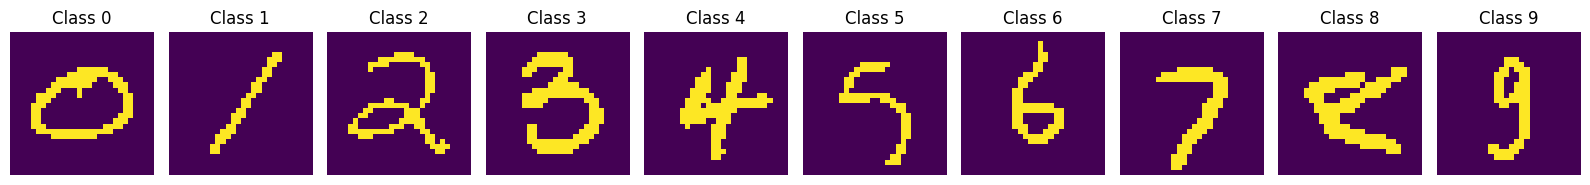

In [7]:
def plot_digits(X_train, y_train, num_classes=10):
    fig, axes = plt.subplots(1,num_classes, figsize=(16, 6))

    for cls in range(num_classes):
        # Select a random image from the class
        class_indices = np.where(y_train == cls)[0]
        random_index = np.random.choice(class_indices)
        random_image = X_train[random_index]

        # Plot the random image
        axes[cls].imshow(random_image)
        axes[cls].set_title(f"Class {cls}")
        axes[cls].axis("off")

    plt.tight_layout()

plot_digits(X_train, y_train)

In [8]:
# Helper function for Laplace smoothing
def laplace_smoothing(count, total, alpha=1, coef=2):
    return (count + alpha) / (total + coef * alpha)


# Naive Bayes Classifier
class NaiveBayesClassifier:
    def __init__(self, num_classes=10):
        self.num_classes = num_classes
        self.P_y = None  # Prior probabilities P(y)
        self.P_xy = None  # Conditional probabilities P(x|y)

    def train(self, X, y):
        print("Training NaiveBayes...")
        n_samples, H, W = X.shape
        self.P_y = np.zeros(self.num_classes)  # Initialize P(y)
        self.P_xy = np.zeros((self.num_classes, H, W, 2))  # P(x|y), separate for active/inactive

        # Compute P(y)
        for cls in range(self.num_classes):
            self.P_y[cls] = np.sum(y == cls) / n_samples

        # Compute P(x|y) with Laplace smoothing
        for cls in range(self.num_classes):
            X_cls = X[y == cls]  # Select samples belonging to class `cls`
            self.P_xy[cls, :, :, 1] = (np.sum(X_cls, axis=0) + 1) / (X_cls.shape[0] + 2)
            self.P_xy[cls, :, :, 0] = 1 - self.P_xy[cls, :, :, 1]  # Complement for inactive pixels

    def predict(self, X):
        print("Testing NaiveBayes...")
        n_samples, H, W = X.shape
        log_likelihood = np.zeros((n_samples, self.num_classes))

        # Compute log P(y) + sum(log P(x|y)) for each class
        for cls in range(self.num_classes):
            log_prior = np.log(self.P_y[cls])
            log_conditional = (
                X * np.log(self.P_xy[cls, :, :, 1]) + 
                (1 - X) * np.log(self.P_xy[cls, :, :, 0])
            ).sum(axis=(1, 2))
            log_likelihood[:, cls] = log_prior + log_conditional

        # Predict the class with the highest log likelihood
        predictions = np.argmax(log_likelihood, axis=1)
        return predictions

In [9]:
# Logistic Regression Classifier
class LogisticRegressionClassifier:
    def __init__(self, num_classes=10):
        self.num_classes = num_classes
        # Initialize logistic regression model
        self.lr_model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')

    def train(self, X, y):
        print("Training logistic regression...")
        # Train the logistic regression model
        self.lr_model.fit(X, y)

    def predict(self, X):
        print("Predicting with logistic regression...")
        # Predict using the trained model
        predictions = self.lr_model.predict(X)
        return predictions
    
    def get_weights(self):
        if self.lr_model is None:
            return None
        # Return the learned weights for visualization
        return self.lr_model.coef_

In [10]:
# Train and Evaluate Naive Bayes Classifier
nb_classifier = NaiveBayesClassifier()
nb_classifier.train(X_train, y_train)
nb_preds = nb_classifier.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_preds)
print(f"Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

# Train and Evaluate Logistic Regression Classifier
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train.reshape(-1, n))
X_test_lr = scaler.transform(X_test.reshape(-1, n))
lr_classifier = LogisticRegressionClassifier()
lr_classifier.train(X_train_lr, y_train)
lr_preds = lr_classifier.predict(X_test_lr)
lr_accuracy = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")


Training NaiveBayes...
Testing NaiveBayes...
Naive Bayes Accuracy: 83.59%
Training logistic regression...


c:\Users\Jahanvi B Dinesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Predicting with logistic regression...
Logistic Regression Accuracy: 90.37%


Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...


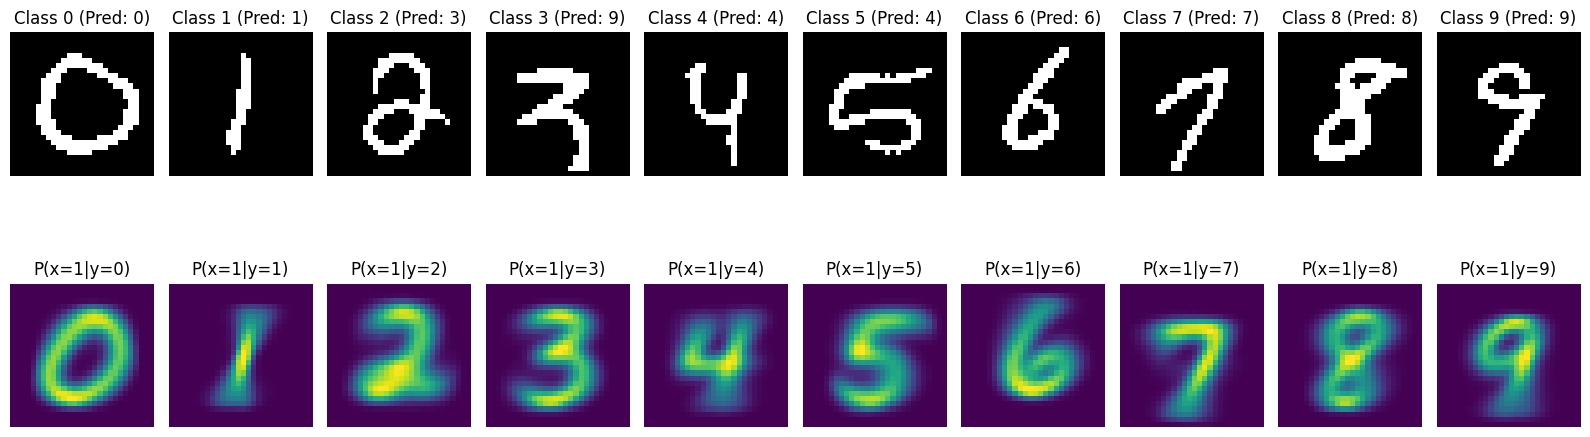

In [12]:
# Function to plot a random image and its corresponding P_xy for each class
def plot_random_image_and_p_xy(nb_classifier, X_test, y_test, num_classes=10):
    H, W = X_test.shape[1], X_test.shape[2]  # Assuming X_test is (n_samples, H, W)
    fig, axes = plt.subplots(2, num_classes, figsize=(16, 6))

    for cls in range(num_classes):
        # Select a random image from the class
        class_indices = np.where(y_test == cls)[0]
        random_index = np.random.choice(class_indices)
        random_image = X_test[random_index]
        prediction = nb_classifier.predict(random_image.reshape(1, H, W))[0]

        # Plot the random image
        axes[0, cls].imshow(random_image, cmap="gray")
        axes[0, cls].set_title(f"Class {cls} (Pred: {int(prediction)})")
        axes[0, cls].axis("off")

        # Plot the P(x=1|y=cls)
        axes[1, cls].imshow(nb_classifier.P_xy[cls, :, :, 1], cmap="viridis")
        axes[1, cls].set_title(f"P(x=1|y={cls})")
        axes[1, cls].axis("off")

    plt.tight_layout()
    plt.show()

# Example usage
plot_random_image_and_p_xy(nb_classifier, X_test.reshape(-1, 28, 28), y_test)

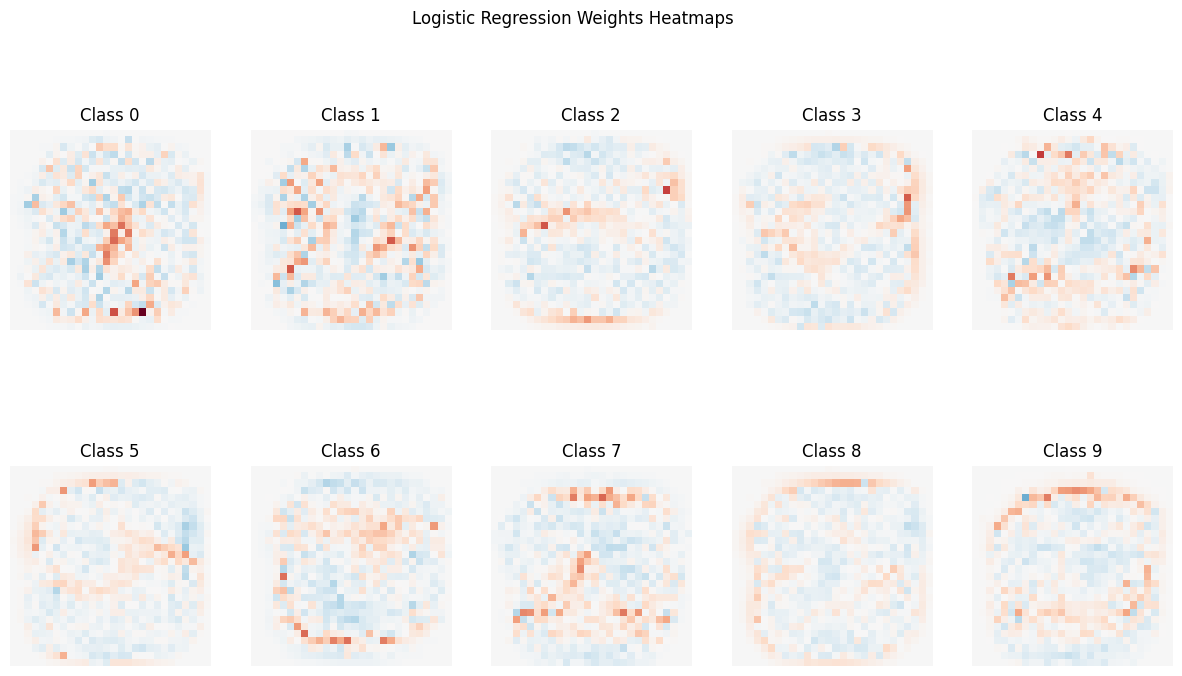

In [13]:
# Visualize weights for each class
coef = lr_classifier.get_weights()
if coef is None:
    print("No weights found")
    coef = np.random.randn(10, 28, 28)
weights = coef.reshape(10, 28, 28)
scale = np.abs(coef).max()

plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        weights[i],
        interpolation="nearest",
        cmap=plt.cm.RdBu,
        vmin=-scale,
        vmax=scale,
    )
    plt.title(f"Class {i}")
    plt.axis("off")
plt.suptitle("Logistic Regression Weights Heatmaps")
plt.show()